In [1]:
import pandas as pd
from pathlib import Path

DATA_PATH = Path("../data/raw/PS_20174392719_1491204439457_log.csv")

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

df.head()

Dataset loaded successfully
Rows: 6,362,620
Columns: 11


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [3]:
print(df.columns.tolist())

['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']


In [4]:
missing = df.isnull().sum()
print(missing[missing > 0])

Series([], dtype: int64)


In [5]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [6]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [7]:
print(
    df["isFraud"]
    .value_counts(normalize=True)
    .mul(100)
    .round(4)
)

isFraud
0    99.8709
1     0.1291
Name: proportion, dtype: float64


In [8]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
step,6362620.0,NaN,NaN,NaN,243.397246,142.331971,1.0,156.0,239.0,335.0,743.0
type,6362620,5,CASH_OUT,2237500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
amount,6362620.0,NaN,NaN,NaN,179861.903549,603858.231463,0.0,13389.57,74871.94,208721.4775,92445516.64
nameOrig,6362620,6353307,C1677795071,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
oldbalanceOrg,6362620.0,NaN,NaN,NaN,833883.104074,2888242.673038,0.0,0.0,14208.0,107315.175,59585040.37
newbalanceOrig,6362620.0,NaN,NaN,NaN,855113.668579,2924048.502954,0.0,0.0,0.0,144258.41,49585040.37
nameDest,6362620,2722362,C1286084959,113,NaN,NaN,NaN,NaN,NaN,NaN,NaN
oldbalanceDest,6362620.0,NaN,NaN,NaN,1100701.66652,3399180.112994,0.0,0.0,132705.665,943036.7075,356015889.35
newbalanceDest,6362620.0,NaN,NaN,NaN,1224996.398202,3674128.94212,0.0,0.0,214661.44,1111909.25,356179278.92
isFraud,6362620.0,NaN,NaN,NaN,0.001291,0.035905,0.0,0.0,0.0,0.0,1.0


In [9]:
print(df["type"].value_counts())

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64


In [10]:
pd.crosstab(
    df["type"],
    df["isFraud"],
    margins=True
)

isFraud,0,1,All
type,,,
CASH_IN,1399284,0,1399284
CASH_OUT,2233384,4116,2237500
DEBIT,41432,0,41432
PAYMENT,2151495,0,2151495
TRANSFER,528812,4097,532909
All,6354407,8213,6362620


### EDA

#### Now we analyze why the transactions look different, especially legitimate vs fraudulent transactions.

##### 1. Start with class distribution

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

fraud_counts = df["isFraud"].value_counts()
print(fraud_counts)

isFraud
0    6354407
1       8213
Name: count, dtype: int64


In [12]:
fraud_percentage = (
    df["isFraud"]
    .value_counts(normalize=True)
    .mul(100)
    .round(4)
)

print(fraud_percentage)

isFraud
0    99.8709
1     0.1291
Name: proportion, dtype: float64


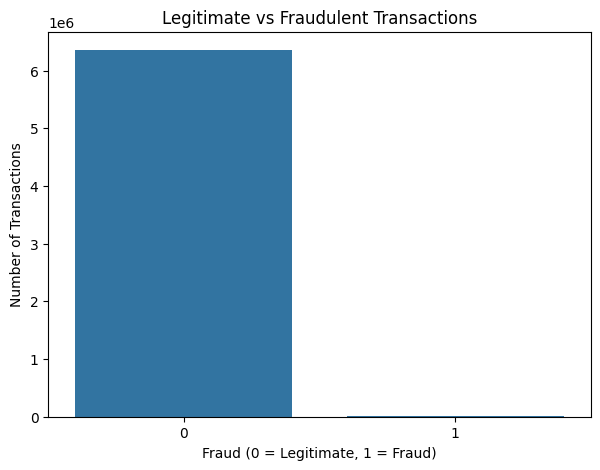

In [13]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="isFraud"
)

plt.title("Legitimate vs Fraudulent Transactions")
plt.xlabel("Fraud (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Number of Transactions")

plt.show()

##### 2. Analyze transaction types

In [14]:
type_counts = df["type"].value_counts()

print(type_counts)

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64


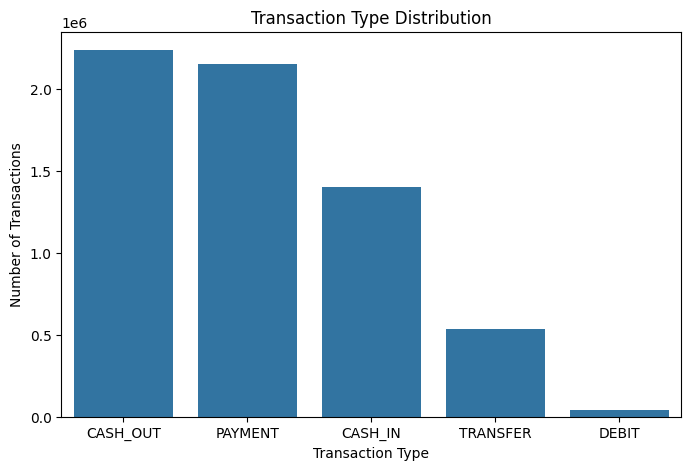

In [15]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="type",
    order=df["type"].value_counts().index
)

plt.title("Transaction Type Distribution")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")

plt.show()

##### 3. Fraud by transaction type

##### This is one of the most important EDA analyses for this dataset.

In [16]:
fraud_by_type = pd.crosstab(
    df["type"],
    df["isFraud"]

)

print(fraud_by_type)

isFraud         0     1
type                   
CASH_IN   1399284     0
CASH_OUT  2233384  4116
DEBIT       41432     0
PAYMENT   2151495     0
TRANSFER   528812  4097


In [17]:
fraud_rate_by_type = (
    df.groupby("type")["isFraud"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print(fraud_rate_by_type)

type
TRANSFER    0.768799
CASH_OUT    0.183955
CASH_IN     0.000000
DEBIT       0.000000
PAYMENT     0.000000
Name: isFraud, dtype: float64


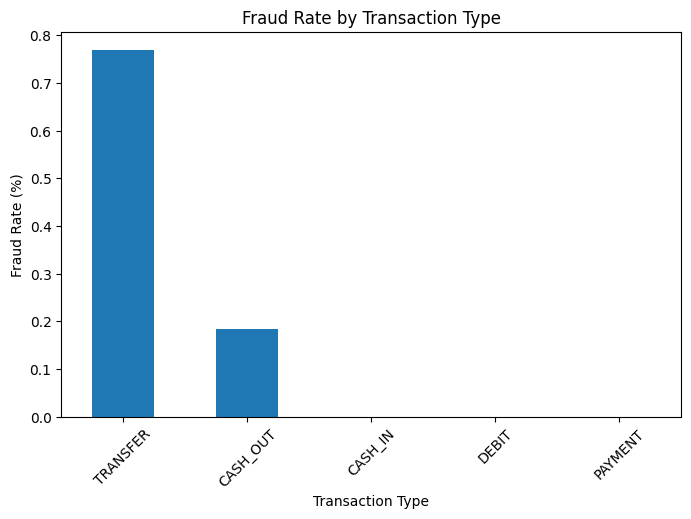

In [18]:
plt.figure(figsize=(8, 5))

fraud_rate_by_type.plot(kind="bar")

plt.title("Fraud Rate by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=45)

plt.show()

##### 4. Analyze transaction amounts

##### First check the overall distribution:

In [19]:
print(df["amount"].describe())

count    6.362620e+06
mean     1.798619e+05
std      6.038582e+05
min      0.000000e+00
25%      1.338957e+04
50%      7.487194e+04
75%      2.087215e+05
max      9.244552e+07
Name: amount, dtype: float64


In [20]:
amount_summary = (
    df.groupby("isFraud")["amount"]
    .agg(["count", "mean", "median", "min", "max"])
)

print(amount_summary)

           count          mean     median   min          max
isFraud                                                     
0        6354407  1.781970e+05   74684.72  0.01  92445516.64
1           8213  1.467967e+06  441423.44  0.00  10000000.00


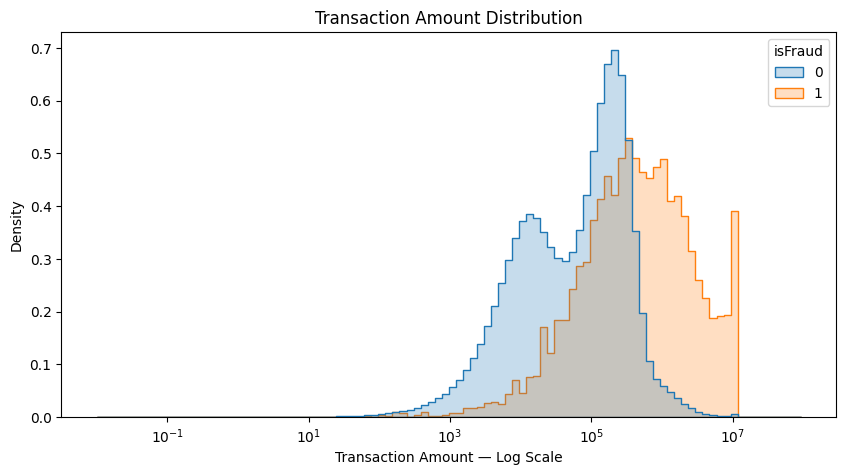

In [21]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="amount",
    hue="isFraud",
    bins=100,
    log_scale=True,
    element="step",
    stat="density",
    common_norm=False
)

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount — Log Scale")
plt.ylabel("Density")

plt.show()

##### 5. Analyze sender balance behavior

In [22]:
balance_columns =[
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest"
]

df[balance_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
oldbalanceOrg,6362620.0,8.338831e+05,2.888243e+06,0.0,0.0,14208.000,1.073152e+05,5.958504e+07
newbalanceOrig,6362620.0,8.551137e+05,2.924049e+06,0.0,0.0,0.000,1.442584e+05,4.958504e+07
oldbalanceDest,6362620.0,1.100702e+06,3.399180e+06,0.0,0.0,132705.665,9.430367e+05,3.560159e+08
newbalanceDest,6362620.0,1.224996e+06,3.674129e+06,0.0,0.0,214661.440,1.111909e+06,3.561793e+08


In [23]:
df.groupby("isFraud")[
    ["oldbalanceOrg", "newbalanceOrig"]
].median()

,oldbalanceOrg,newbalanceOrig
isFraud,,
0,14069.00,0.0
1,438983.45,0.0


In [24]:
df.groupby("isFraud")[
    ["oldbalanceDest", "newbalanceDest"]
].median()

,oldbalanceDest,newbalanceDest
isFraud,,
0,133311.8,214881.70
1,0.0,4676.42


##### 6. Investigate isFlaggedFraud
##### This is important because it is already a fraud-related flag in the original dataset.

In [25]:
print(df["isFlaggedFraud"].value_counts())

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64


In [26]:
pd.crosstab(
    df["isFlaggedFraud"],
    df['isFraud'],
    margins=True
)

isFraud,0,1,All
isFlaggedFraud,,,
0,6354407,8197,6362604
1,0,16,16
All,6354407,8213,6362620


##### 7. Fraud distribution over time

##### step represents the simulation time step.

In [27]:
fraud_by_step = (
    df.groupby("step")["isFraud"]
    .sum()
)

print(fraud_by_step.head())

step
1    16
2     8
3     4
4    10
5     6
Name: isFraud, dtype: int64


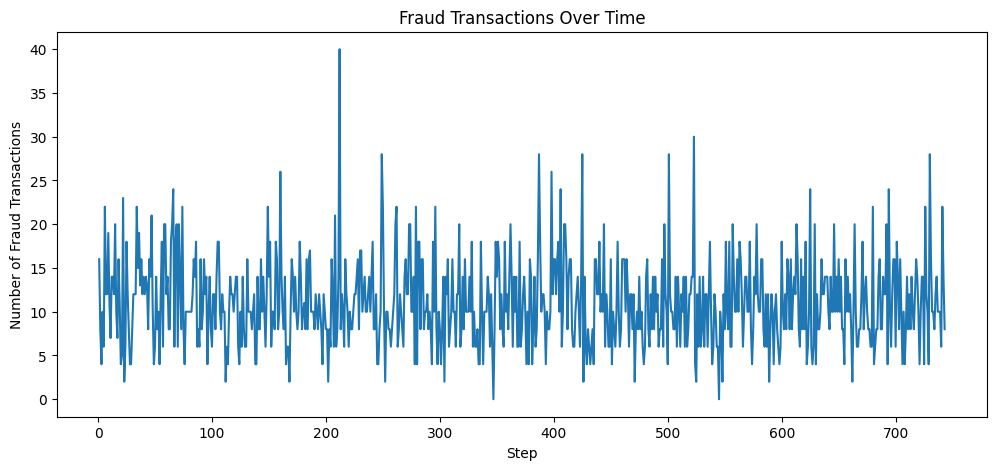

In [28]:
plt.figure(figsize=(12, 5))

fraud_by_step.plot()

plt.title("Fraud Transactions Over Time")
plt.xlabel("Step")
plt.ylabel("Number of Fraud Transactions")

plt.show()

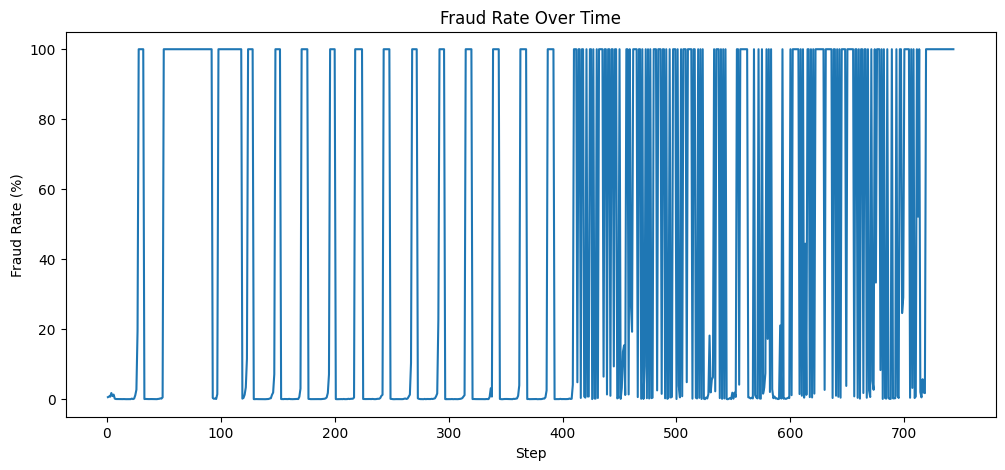

In [29]:
fraud_rate_by_step = (
    df.groupby("step")["isFraud"]
    .mean()
    .mul(100)
)

plt.figure(figsize=(12, 5))

fraud_rate_by_step.plot()

plt.title("Fraud Rate Over Time")
plt.xlabel("Step")
plt.ylabel("Fraud Rate (%)")

plt.show()

##### 8. Correlation analysis

##### For the numerical variables:

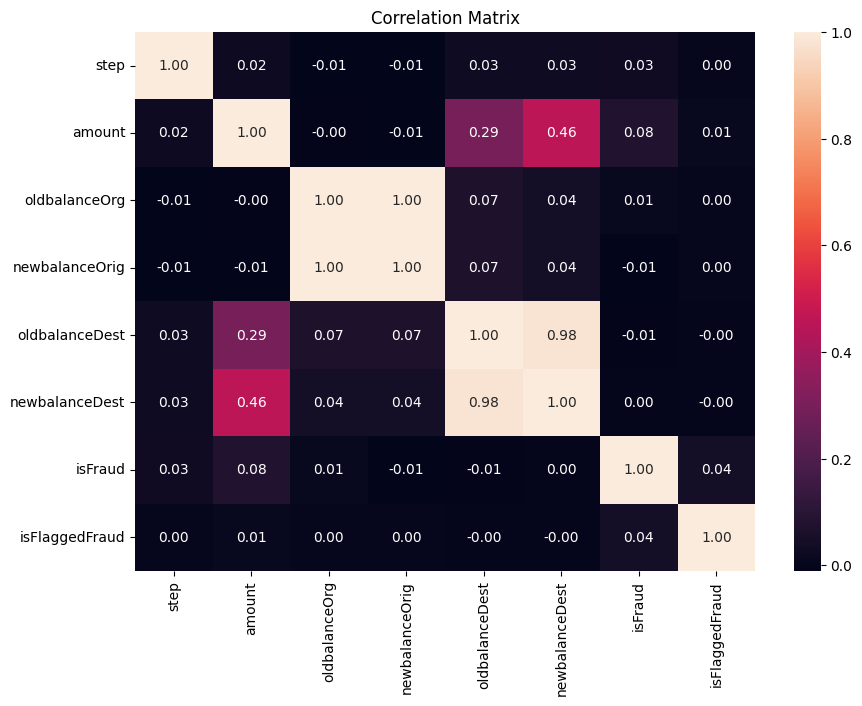

In [30]:
numeric_columns = [
    "step",
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "isFraud",
    "isFlaggedFraud"
]

correlation = df[numeric_columns].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [31]:
correlation = df[numeric_columns].corr()

display(correlation)

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
step,1.000000,0.022373,-0.010058,-0.010299,0.027665,0.025888,0.031578,0.003277
amount,0.022373,1.000000,-0.002762,-0.007861,0.294137,0.459304,0.076688,0.012295
oldbalanceOrg,-0.010058,-0.002762,1.000000,0.998803,0.066243,0.042029,0.010154,0.003835
newbalanceOrig,-0.010299,-0.007861,0.998803,1.000000,0.067812,0.041837,-0.008148,0.003776
oldbalanceDest,0.027665,0.294137,0.066243,0.067812,1.000000,0.976569,-0.005885,-0.000513
newbalanceDest,0.025888,0.459304,0.042029,0.041837,0.976569,1.000000,0.000535,-0.000529
isFraud,0.031578,0.076688,0.010154,-0.008148,-0.005885,0.000535,1.000000,0.044109
isFlaggedFraud,0.003277,0.012295,0.003835,0.003776,-0.000513,-0.000529,0.044109,1.000000


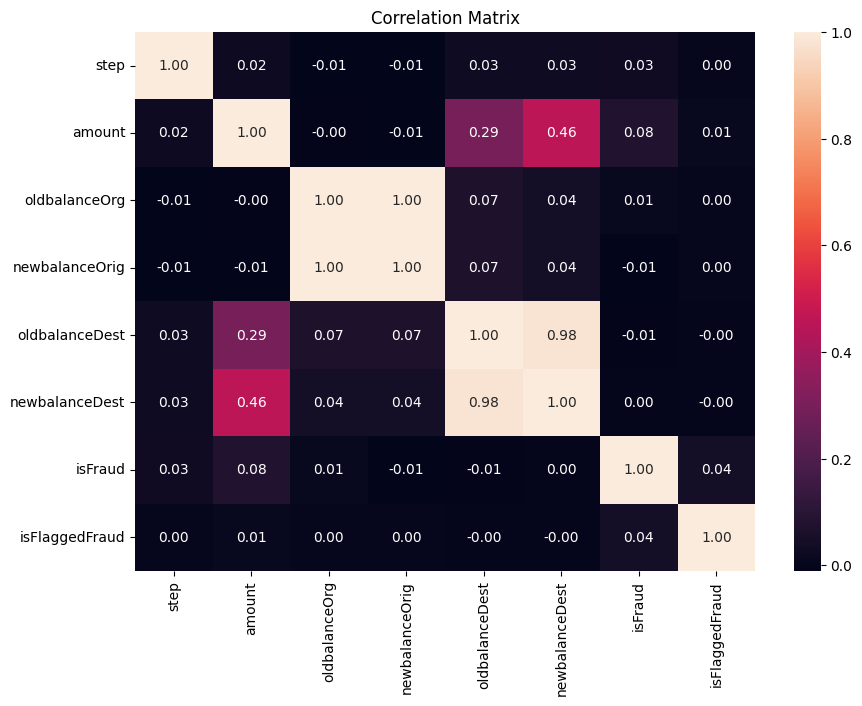

In [32]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()